In [1]:
import numpy as np
import scipy 
import matplotlib.pyplot as plt
import cvxpy as cp
import os
from time import time
import pickle
import sys
import pandas as pd
from sklearn.model_selection import train_test_split

# Assuming these imports contain the external functions: counts, fidelity, run_experiment, etc.
from uq_utils import *
from utils import qst1
from run_conformal import *
from cqr import helper
from nonconformist.nc import RegressorNc, AbsErrorErrFunc, RegressorNormalizer
from nonconformist.nc import QuantileRegErrFunc, QuantileRegAsymmetricErrFunc

# --- 1. CORE PHYSICS FUNCTIONS ---

def randomState(nQubits, rank):  
    vec = np.random.randn(2**nQubits, rank) + 1j * np.random.randn(2**nQubits, rank)
    state = vec @ vec.conj().T
    return state / np.trace(state)

def rho_theta(theta, rho1, rho2):
    return theta * rho1 + (1 - theta) * rho2

def generate_misspecified_state(theta, rho1, rho2, epsilon, nQubits):
    rho_model = rho_theta(theta, rho1, rho2)
    if epsilon == 0:
        return rho_model
    rho_noise = randomState(nQubits, rank=1) 
    rho_actual = (1 - epsilon) * rho_model + epsilon * rho_noise
    return rho_actual / np.trace(rho_actual)

def born_probs(rho, nQubits):
    fi = qst1(rho, nQubits) 
    return np.real_if_close(0.5 * (fi[0] + fi[1:]))

def generate_dataset(n_samples, nQubits, N, eps, rho1, rho2, sigma):
    X = []
    y = []
    thetas = []
    for _ in range(n_samples):
        theta = np.random.uniform(0, 1)
        rho_model = rho_theta(theta, rho1, rho2)
        
        if eps == 0:
            rho_actual = rho_model
        else:
            rho_noise = randomState(nQubits, rank=1) 
            rho_actual = (1 - eps) * rho_model + eps * rho_noise 
            rho_actual /= np.trace(rho_actual)
            
        meas = counts(rho_actual, nQubits, N)
        f_actual = np.real(fidelity(rho_actual, sigma)) 
        
        X.append(meas)
        y.append(f_actual)
        thetas.append(theta)
        
    return np.array(X), np.array(y), thetas

# --- 2. THE UNIFIED MAIN LOOP ---

nQubits = 2
N = 100           
alpha = 0.1        
n_samples_total = 10000
n_splits = 2
epsilons = np.arange(0.0, 0.05, 0.02)
theta_grid = np.linspace(0, 1, 1000)
save_path = "./results"
os.makedirs(save_path, exist_ok=True)
save = True

sigma = randomState(nQubits, 1)
rho1_base = randomState(nQubits, 1)
delta_fix = 0.2
rho1 = (1-delta_fix)*sigma + delta_fix*rho1_base; rho1 /= np.trace(rho1)
rho2 = sigma; rho2 /= np.trace(rho2)

F_1 = np.real(fidelity(rho1, sigma))
F_2 = np.real(fidelity(rho2, sigma))

# -----------------------------------------------------
# BAYESIAN PRECOMPUTATION
# -----------------------------------------------------
# We calculate the base probabilities for all 1000 theta points once.
prob_grid = []
for theta in theta_grid:
    rho = rho_theta(theta, rho1, rho2)
    p_base = born_probs(rho, nQubits)
    prob = np.hstack([p_base, 1 - p_base])
    prob = np.clip(prob, 1e-12, 1.0)
    prob_grid.append(prob)

# Take the log
log_prob_grid = np.log(np.array(prob_grid))
# -----------------------------------------------------

records = []

for eps in epsilons:
    print(f"\n{'='*40}")
    print(f"Running Analysis for Epsilon = {eps:.2f}")
    print(f"{'='*40}")
    
    X, Y, thetas = generate_dataset(n_samples_total, nQubits, N, eps, rho1, rho2, sigma)
    
    for i in range(n_splits):
        print(f"  --> Split {i+1}/{n_splits}...")
        
        x_train, x_test, y_train, y_test, _, thetas_test = train_test_split(
            X, Y.ravel(), thetas, test_size=0.2, random_state=i
        )

        x_train = np.asarray(x_train).astype(np.float32)
        y_train = np.asarray(y_train).astype(np.float32)
        x_test = np.asarray(x_test).astype(np.float32)
        y_test = np.asarray(y_test).astype(np.float32)

        n_train = x_train.shape[0]
        n_test = x_test.shape[0]

        idx = np.random.permutation(n_train)
        n_half = int(np.floor(n_train/2))
        idx_train, idx_cal = idx[:n_half], idx[n_half:2*n_half]

        # -----------------------------------------------------
        # METHOD A: CONFORMAL PREDICTION (Neural Net)
        # -----------------------------------------------------
        cp_cov, cp_len, y_lower, y_upper, cp_time, _ = run_experiment(
            'Neural Net', nQubits, x_train, y_train, x_test, y_test, idx_train, idx_cal, alpha
        )
        
        records.append({
            "nQubits": nQubits, "nShots": N, "iter": i, "epsilon": eps,
            "method": 'CP',
            "coverage": cp_cov/100,
            "avg_length": cp_len,
            "time": cp_time
        })

        # -----------------------------------------------------
        # METHOD B: BAYESIAN INFERENCE
        # -----------------------------------------------------
        bayes_cov_list = []
        bayes_len_list = []
        
        start_bayes = time.time()
        
        for j in range(n_test):
            # Multiply to return to raw counts (assuming x_test was normalized to frequencies)
            counts_obs = x_test[j] * N
            f_actual = y_test[j]

            # 1. Fast Vectorized Posterior
            # (counts_obs * log_prob_grid) broadcasts counts across the 1000 grid points natively
            logL = np.sum(counts_obs * log_prob_grid, axis=1)
            logL -= np.max(logL)
            posterior = np.exp(logL)
            post_pmf = posterior / np.sum(posterior)

            # 2. Extract HPD Density Threshold
            sorted_pmf = np.sort(post_pmf)[::-1]
            cum_sorted = np.cumsum(sorted_pmf)
            threshold_idx = np.searchsorted(cum_sorted, 1 - alpha)
            density_threshold = sorted_pmf[threshold_idx]

            # 3. Get Theta Bounds
            in_hpd = np.where(post_pmf >= density_threshold)[0]
            theta_lo = theta_grid[in_hpd[0]]
            theta_hi = theta_grid[in_hpd[-1]]

            # 4. Pushforward to Fidelity Domain linearly
            f_bound_A = theta_lo * F_1 + (1 - theta_lo) * F_2
            f_bound_B = theta_hi * F_1 + (1 - theta_hi) * F_2

            f_lo = min(f_bound_A, f_bound_B)
            f_hi = max(f_bound_A, f_bound_B)
            
            bayes_cov_list.append(f_lo <= f_actual <= f_hi)
            bayes_len_list.append(f_hi - f_lo)
            
        bayes_time = time.time() - start_bayes
        
        records.append({
            "nQubits": nQubits, "nShots": N, "iter": i, "epsilon": eps,
            "method": 'Bayes',
            "coverage": np.mean(bayes_cov_list),
            "avg_length": np.mean(bayes_len_list),
            "time": bayes_time
        })
# --- 3. SAVE RESULTS ---
df = pd.DataFrame(records)

if save:
    df.to_csv(os.path.join(save_path, "bayes.csv"), index=False)

using device: mps

Running Analysis for Epsilon = 0.00
  --> Split 1/2...
  --> Split 2/2...

Running Analysis for Epsilon = 0.02
  --> Split 1/2...
  --> Split 2/2...

Running Analysis for Epsilon = 0.04
  --> Split 1/2...
  --> Split 2/2...


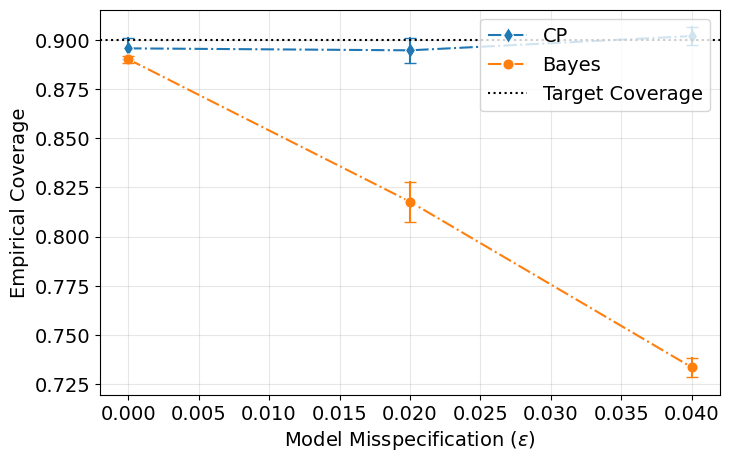

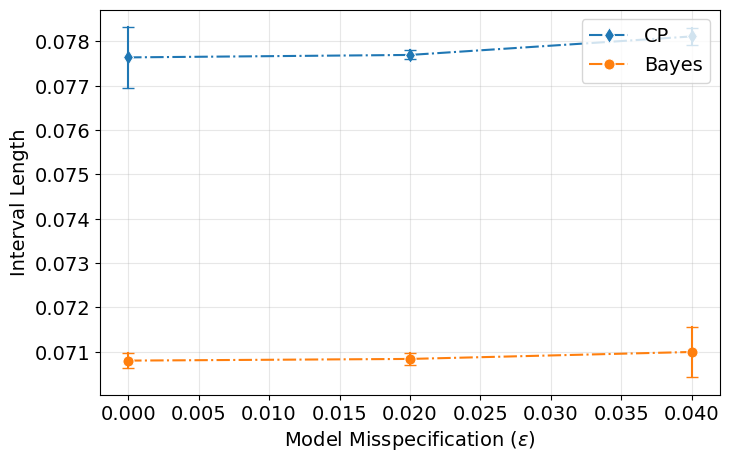

In [2]:
import seaborn as sns
plt.rcParams.update({'font.size': 14})


df = pd.DataFrame(records)
# 1. Aggregate Data
summary = df.copy()
summary = summary.groupby(["epsilon", "method"]).agg(
    mean_cov=("coverage", "mean"),
    mean_len=("avg_length", "mean"),
    std_cov=("coverage", "std"),
    n_runs=("coverage", "count")
).reset_index()
# Compute 95% Confidence Intervals
summary["ci_cov"] = 1.96 * (summary["std_cov"] / np.sqrt(summary["n_runs"]))

# 2. Plot Coverage Comparison
plt.figure(figsize=(8, 5))
sns.lineplot(
    data=df, x="epsilon", y="coverage", hue="method",markersize = 8 ,style='method',dashes=False, err_kws={"capsize": 4},
    markers=["d", "o"], linestyle = "-.",err_style="bars", errorbar=("ci", 95)
)
plt.rcParams.update({'font.size': 14})
plt.axhline(0.9, linestyle='dotted', color='black', label="Target Coverage")
plt.xlabel(r"Model Misspecification ($\epsilon$)")
plt.ylabel("Empirical Coverage")
# plt.title("Conformal Prediction vs. Bayesian\nUnder Model Misspecification")
plt.legend(loc='upper right')
# plt.ylim(np.arange(0, 110, 20))
plt.grid(True, alpha=0.3)
plt.savefig(os.path.join(save_path, "bayes_cov.pdf"), bbox_inches='tight', dpi=300)
plt.show()

# 3. Plot Interval Length Comparison
plt.figure(figsize=(8, 5))
sns.lineplot(
    data=df, x="epsilon", y="avg_length", hue="method",markersize = 8 , style = 'method',dashes=False, err_kws={"capsize": 4},
    markers=["d", "o"], linestyle = "-.", err_style="bars", errorbar=("ci", 95)
)
plt.rcParams.update({'font.size': 14})
plt.xlabel(r"Model Misspecification ($\epsilon$)")
plt.ylabel("Interval Length")
# plt.title("Interval Width Comparison")
plt.legend(loc='upper right')
plt.grid(True, alpha=0.3)
plt.savefig(os.path.join(save_path, "bayes_len.pdf"), bbox_inches='tight', dpi=300)
plt.show()

generate train for $\epsilon = 0$, generate cal for varying $\epsilon$ and test for fixed $\epsilon$ 

In [ ]:
records_case2 = []
records_case4 = []

# Define standard slice sizes to ensure fair comparisons
n_samples_total = 10000
n_train = 4000
n_cal = 4000
n_test = 2000 # Total 10000 samples
n_splits = 10

for eps in epsilons:
    print(f"\n{'='*50}")
    print(f"Running Distribution Shift Analysis | Epsilon = {eps:.2f}")
    print(f"{'='*50}")
    
    # 1. Generate Two Distinct Universes of Data
    # P_e=0 (The Perfect Physics Simulation)
    X_ideal, Y_ideal, _ = generate_dataset(n_samples_total, nQubits, N, 0.0, rho1, rho2, sigma)
    # P_e (The Messy Physical Reality)
    X_real, Y_real, _ = generate_dataset(n_samples_total, nQubits, N, eps, rho1, rho2, sigma)
    
    for i in range(n_splits):
        print(f"  --> Split {i+1}/{n_splits}...")
        
        # Shuffle indices to ensure random splits per iteration
        idx_ideal = np.random.permutation(n_samples_total)
        idx_real = np.random.permutation(n_samples_total)

        # ------------------------------------------------------------------
        # CASE 2: The Robustness Test (Train ~ P_ideal | Cal ~ P_real | Test ~ P_real)
        # ------------------------------------------------------------------
        # Grab training data from Ideal
        tr_idx_c2 = idx_ideal[:n_train]
        # Grab calibration and test data from Real
        cal_idx_c2 = idx_real[n_train : n_train + n_cal]
        te_idx_c2  = idx_real[n_train + n_cal : n_train + n_cal + n_test]

        # Stitch Train and Cal together for the CP API
        x_train_c2 = np.vstack([X_ideal[tr_idx_c2], X_real[cal_idx_c2]]).astype(np.float32)
        y_train_c2 = np.hstack([Y_ideal[tr_idx_c2], Y_real[cal_idx_c2]]).astype(np.float32)
        
        # Define the indices for the CP API based on our stitched array
        idx_train_c2 = np.arange(0, n_train)
        idx_cal_c2 = np.arange(n_train, n_train + n_cal)
        
        x_test_c2 = np.asarray(X_real[te_idx_c2]).astype(np.float32)
        y_test_c2 = np.asarray(Y_real[te_idx_c2]).astype(np.float32)

        # Run Conformal Prediction for Case 2
        cp_cov_c2, cp_len_c2, _, _, cp_time_c2, _ = run_experiment(
            'Neural Net', nQubits, x_train_c2, y_train_c2, x_test_c2, y_test_c2, idx_train_c2, idx_cal_c2, alpha
        )
        
        records_case2.append({
            "nQubits": nQubits, "nShots": N, "iter": i, "epsilon": eps,
            "method": 'Neural Net (Case 2)',
            "coverage": cp_cov_c2 / 100,
            "avg_length": cp_len_c2,
            "time": cp_time_c2
        })

        # ------------------------------------------------------------------
        # CASE 4: Complete OOD Shift (Train ~ P_ideal | Cal ~ P_ideal | Test ~ P_real)
        # ------------------------------------------------------------------
        # Grab training AND calibration data from Ideal
        tr_idx_c4  = idx_ideal[:n_train]
        cal_idx_c4 = idx_ideal[n_train : n_train + n_cal]
        # Test data is STILL from Real
        te_idx_c4  = idx_real[n_train + n_cal : n_train + n_cal + n_test]

        # Stitch Train and Cal together (Both Ideal here)
        x_train_c4 = np.vstack([X_ideal[tr_idx_c4], X_ideal[cal_idx_c4]]).astype(np.float32)
        y_train_c4 = np.hstack([Y_ideal[tr_idx_c4], Y_ideal[cal_idx_c4]]).astype(np.float32)
        
        # Define indices
        idx_train_c4 = np.arange(0, n_train)
        idx_cal_c4 = np.arange(n_train, n_train + n_cal)
        
        x_test_c4 = np.asarray(X_real[te_idx_c4]).astype(np.float32)
        y_test_c4 = np.asarray(Y_real[te_idx_c4]).astype(np.float32)

        # Run Conformal Prediction for Case 4
        cp_cov_c4, cp_len_c4, _, _, cp_time_c4, _ = run_experiment(
            'Neural Net', nQubits, x_train_c4, y_train_c4, x_test_c4, y_test_c4, idx_train_c4, idx_cal_c4, alpha
        )
        
        records_case4.append({
            "nQubits": nQubits, "nShots": N, "iter": i, "epsilon": eps,
            "method": 'Neural Net (Case 4)',
            "coverage": cp_cov_c4 / 100,
            "avg_length": cp_len_c4,
            "time": cp_time_c4
        })

        # ------------------------------------------------------------------
        # BAYESIAN EVALUATION (Evaluated on P_real to match the test sets)
        # ------------------------------------------------------------------
        # We can evaluate Bayes against the test set from Case 2 (which is drawn from P_real)
        bayes_cov_list = []
        bayes_len_list = []
        start_bayes = time.time()
        
        for j in range(n_test):
            counts_obs = x_test_c2[j] * N
            f_actual = y_test_c2[j]

            # 1. Fast Vectorized Posterior
            logL = np.sum(counts_obs * log_prob_grid, axis=1)
            logL -= np.max(logL)
            posterior = np.exp(logL)
            post_pmf = posterior / np.sum(posterior)

            # 2. Extract HPD Density Threshold Safely
            sorted_pmf = np.sort(post_pmf)[::-1]
            cum_sorted = np.cumsum(sorted_pmf)
            threshold_idx = np.searchsorted(cum_sorted, 1 - alpha)
            threshold_idx = min(threshold_idx, len(sorted_pmf) - 1)
            density_threshold = sorted_pmf[threshold_idx]

            # 3. Get Theta Bounds Safely
            in_hpd = np.where(post_pmf >= density_threshold)[0]
            if len(in_hpd) == 0:
                map_idx = np.argmax(post_pmf)
                theta_lo, theta_hi = theta_grid[map_idx], theta_grid[map_idx]
            else:
                theta_lo = theta_grid[in_hpd[0]]
                theta_hi = theta_grid[in_hpd[-1]]

            # 4. Pushforward to Fidelity Domain linearly
            f_bound_A = theta_lo * F_1 + (1 - theta_lo) * F_2
            f_bound_B = theta_hi * F_1 + (1 - theta_hi) * F_2

            f_lo = min(f_bound_A, f_bound_B)
            f_hi = max(f_bound_A, f_bound_B)
            
            # Account for float precision
            bayes_cov_list.append((f_lo - 1e-7) <= f_actual <= (f_hi + 1e-7))
            bayes_len_list.append(f_hi - f_lo)
            
        bayes_time = time.time() - start_bayes
        
        # Bayes is the same for Case 2 and 4 because the test set is structurally the same (P_real)
        records_case2.append({
            "nQubits": nQubits, "nShots": N, "iter": i, "epsilon": eps,
            "method": 'Bayes',
            "coverage": np.mean(bayes_cov_list),
            "avg_length": np.mean(bayes_len_list),
            "time": bayes_time
        })
        # Log for Case 4 (Using the exact same calculated Bayes metrics)
        records_case4.append({
            "nQubits": nQubits, "nShots": N, "iter": i, "epsilon": eps,
            "method": 'Bayes',
            "coverage": np.mean(bayes_cov_list),
            "avg_length": np.mean(bayes_len_list),
            "time": bayes_time
        })


Running Distribution Shift Analysis | Epsilon = 0.00
  --> Split 1/10...
  --> Split 2/10...
  --> Split 3/10...
  --> Split 4/10...
  --> Split 5/10...
  --> Split 6/10...
  --> Split 7/10...
  --> Split 8/10...
  --> Split 9/10...
  --> Split 10/10...

Running Distribution Shift Analysis | Epsilon = 0.02
  --> Split 1/10...
  --> Split 2/10...
  --> Split 3/10...
  --> Split 4/10...
  --> Split 5/10...
  --> Split 6/10...
  --> Split 7/10...
  --> Split 8/10...
  --> Split 9/10...
  --> Split 10/10...

Running Distribution Shift Analysis | Epsilon = 0.04
  --> Split 1/10...
  --> Split 2/10...
  --> Split 3/10...
  --> Split 4/10...
  --> Split 5/10...
  --> Split 6/10...
  --> Split 7/10...
  --> Split 8/10...
  --> Split 9/10...
  --> Split 10/10...


In [11]:
pd.DataFrame(records_case2).groupby(["epsilon", "method"]).agg(
    mean_cov=("coverage", "mean"),
    mean_len=("avg_length", "mean"),
    std_cov=("coverage", "std"),
    n_runs=("coverage", "count")
)

mean_cov  mean_len   std_cov  n_runs
epsilon method                                                   
0.00    Bayes                 0.89715  0.042924  0.002148      10
        Neural Net (Case 2)   0.90450  0.048359  0.008219      10
0.02    Bayes                 0.71155  0.042882  0.006747      10
        Neural Net (Case 2)   0.89935  0.059584  0.009310      10
0.04    Bayes                 0.48015  0.041729  0.013577      10
        Neural Net (Case 2)   0.89990  0.080251  0.009732      10